# Chapter 5: Prompt Engineering for Scientific Discovery

## Hands-On Jupyter Notebook

This notebook builds a practical prompt-engineering sandbox for oncology and biomedical tasks using offline examples.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A mini benchmark of biomedical prompt tasks
- Prompt templates for extraction, synthesis, routing, and critique
- A deterministic evaluator for hallucination-risk phrasing
- Structured validators for downstream agent pipelines

---

## Section 1: Setup and Imports

This section configures utilities used to build, test, and compare oncology prompt patterns.

In [1]:
import json
import re
from textwrap import dedent
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('Environment configured for Chapter 5 prompt engineering notebook.')

Environment configured for Chapter 5 prompt engineering notebook.


## Section 2: Build a Prompt Benchmark

We create a compact biomedical benchmark with tasks that require different prompt styles: extraction, synthesis, routing, and critique.

In [2]:
prompt_benchmark = pd.DataFrame(
    [
        {
            'case_id': 'pb_01',
            'task_type': 'extraction',
            'tumor_type': 'lung adenocarcinoma',
            'input_text': 'EGFR L858R detected in lung adenocarcinoma sample. Evidence note recommends curated KB confirmation before treatment interpretation.',
            'required_fields': ['gene', 'alteration', 'tumor_type', 'evidence_statement', 'confidence'],
        },
        {
            'case_id': 'pb_02',
            'task_type': 'synthesis',
            'tumor_type': 'pediatric high-grade glioma',
            'input_text': 'H3F3A K27M is reported in pediatric diffuse midline glioma. Source text emphasizes biology context and asks for cautious interpretation.',
            'required_fields': ['summary', 'supporting_evidence', 'uncertainty_notes'],
        },
        {
            'case_id': 'pb_03',
            'task_type': 'routing',
            'tumor_type': 'breast cancer',
            'input_text': 'ERBB2 amplification documented in metastatic breast cancer report; user asks for trial pre-screening pathway.',
            'required_fields': ['selected_tool', 'rationale', 'requires_human_review'],
        },
        {
            'case_id': 'pb_04',
            'task_type': 'critique',
            'tumor_type': 'colorectal cancer',
            'input_text': 'Draft claim states BRAF V600E always predicts excellent prognosis in colorectal cancer without citing source-level context.',
            'required_fields': ['issues_found', 'severity', 'revision_suggestion'],
        },
    ]
)

display(prompt_benchmark[['case_id', 'task_type', 'tumor_type']])
print(f'Total benchmark rows: {len(prompt_benchmark)}')

,case_id,task_type,tumor_type
0,pb_01,extraction,lung adenocarcinoma
1,pb_02,synthesis,pediatric high-grade glioma
2,pb_03,routing,breast cancer
3,pb_04,critique,colorectal cancer


Total benchmark rows: 4


## Section 3: Prompt Pattern Construction and Evaluation

We generate task-specific prompt templates and compare a loose version against a constrained, schema-first version.

In [3]:
def build_prompt(row: pd.Series, style: str) -> str:
    context = dedent(f'''
    Task type: {row['task_type']}
    Tumor type: {row['tumor_type']}
    Source text: {row['input_text']}
    ''').strip()

    if style == 'loose':
        instruction = 'Write a confident biomedical answer with likely implications.'
    elif style == 'constrained':
        required = ', '.join(row['required_fields'])
        instruction = dedent(f'''
        Return JSON only.
        Required keys: {required}.
        Use only source text evidence.
        If support is weak, set requires_human_review=true or include uncertainty_notes.
        ''').strip()
    else:
        raise ValueError(f'Unsupported style: {style}')

    return f"{context}\n\nInstruction:\n{instruction}"

risky_phrases = [
    r'always predicts',
    r'definitive(ly)?',
    r'guaranteed response',
    r'approved therapy for this case',
]

def simulated_model_output(row: pd.Series, style: str) -> str:
    if style == 'loose' and row['case_id'] in {'pb_02', 'pb_04'}:
        return 'This finding definitively supports a guaranteed response and always predicts favorable outcomes.'
    if style == 'loose':
        return f"{row['task_type']} result for {row['tumor_type']}: high confidence interpretation generated."

    if row['task_type'] == 'extraction':
        return json.dumps({
            'gene': 'EGFR',
            'alteration': 'L858R',
            'tumor_type': row['tumor_type'],
            'evidence_statement': row['input_text'],
            'confidence': 'high',
        })
    if row['task_type'] == 'synthesis':
        return json.dumps({
            'summary': 'H3F3A K27M appears in pediatric glioma context with cautionary interpretation.',
            'supporting_evidence': row['input_text'],
            'uncertainty_notes': 'Actionability not directly established in provided text.',
        })
    if row['task_type'] == 'routing':
        return json.dumps({
            'selected_tool': 'trial_matching',
            'rationale': 'Request explicitly concerns trial pre-screening.',
            'requires_human_review': True,
        })
    return json.dumps({
        'issues_found': ['Unsupported universal claim'],
        'severity': 'high',
        'revision_suggestion': 'Replace absolute language with source-grounded, uncertainty-aware statement.',
    })

rows = []
for _, r in prompt_benchmark.iterrows():
    for style in ['loose', 'constrained']:
        prompt_text = build_prompt(r, style)
        output_text = simulated_model_output(r, style)
        has_risky_phrase = any(re.search(p, output_text.lower()) for p in risky_phrases)
        rows.append({
            'case_id': r['case_id'],
            'task_type': r['task_type'],
            'style': style,
            'prompt_chars': len(prompt_text),
            'output_chars': len(output_text),
            'risky_phrase_flag': has_risky_phrase,
        })

prompt_eval = pd.DataFrame(rows)
display(prompt_eval)

,case_id,task_type,style,prompt_chars,output_chars,risky_phrase_flag
0,pb_01,extraction,loose,275,84,False
1,pb_01,extraction,constrained,420,256,False
2,pb_02,synthesis,loose,286,96,True
3,pb_02,synthesis,constrained,418,337,False
4,pb_03,routing,loose,243,75,False
5,pb_03,routing,constrained,375,131,False
6,pb_04,critique,loose,262,96,True
7,pb_04,critique,constrained,390,172,False


## Section 4: Visual Comparison of Prompt Styles

We compare hallucination-risk flags and response length across loose and constrained prompt styles.

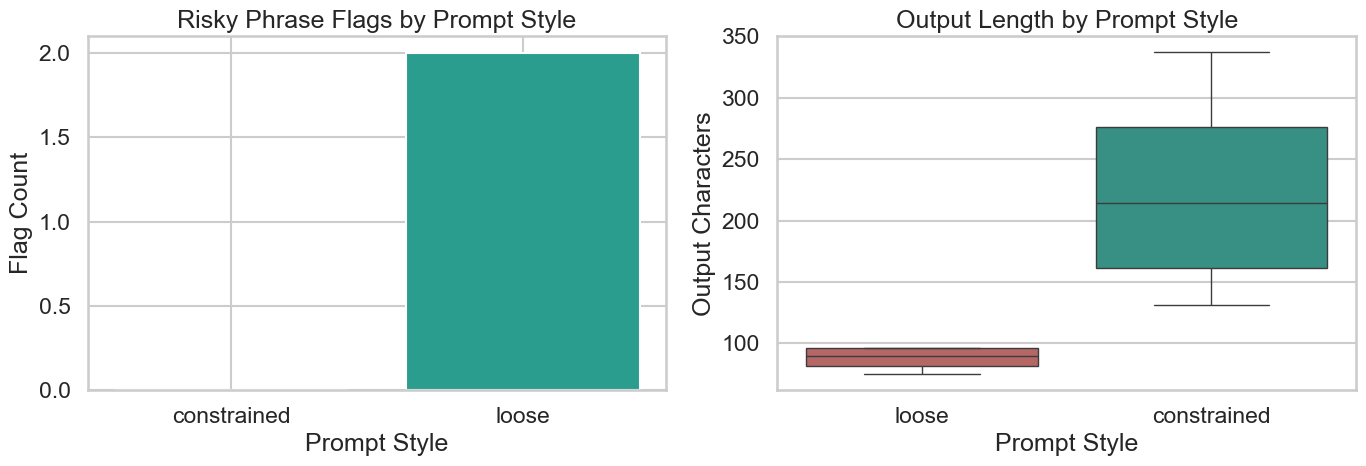

,style,runs,risky_flags,avg_output_chars,risk_rate
0,constrained,4,0,224.00,0.0
1,loose,4,2,87.75,0.5


In [4]:
summary = (
    prompt_eval.groupby('style', as_index=False)
    .agg(
        runs=('case_id', 'count'),
        risky_flags=('risky_phrase_flag', 'sum'),
        avg_output_chars=('output_chars', 'mean'),
    )
)
summary['risk_rate'] = (summary['risky_flags'] / summary['runs']).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary['style'], summary['risky_flags'], color=['#C25B56', '#2A9D8F'])
axes[0].set_title('Risky Phrase Flags by Prompt Style')
axes[0].set_xlabel('Prompt Style')
axes[0].set_ylabel('Flag Count')

sns.boxplot(data=prompt_eval, x='style', y='output_chars', ax=axes[1], palette=['#C25B56', '#2A9D8F'])
axes[1].set_title('Output Length by Prompt Style')
axes[1].set_xlabel('Prompt Style')
axes[1].set_ylabel('Output Characters')

plt.tight_layout()
plt.show()

display(summary)

## Section 5: Exercises

### Exercise 1: Structured Prompt Output Validator

Validate that constrained outputs are parseable JSON and contain expected task-specific fields.

In [5]:
def validate_output(row: pd.Series, output_text: str) -> dict[str, object]:
    try:
        payload = json.loads(output_text)
    except json.JSONDecodeError:
        return {'is_json': False, 'missing': row['required_fields']}

    missing = [k for k in row['required_fields'] if k not in payload]
    return {'is_json': True, 'missing': missing}

validation_rows = []
for _, r in prompt_benchmark.iterrows():
    output_text = simulated_model_output(r, 'constrained')
    check = validate_output(r, output_text)
    validation_rows.append({
        'case_id': r['case_id'],
        'task_type': r['task_type'],
        'is_json': check['is_json'],
        'missing_fields': check['missing'],
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

,case_id,task_type,is_json,missing_fields
0,pb_01,extraction,True,[]
1,pb_02,synthesis,True,[]
2,pb_03,routing,True,[]
3,pb_04,critique,True,[]


### Exercise 2: Prompt Router

Map task types to reusable prompt templates for downstream agent orchestration.

In [6]:
template_router = {
    'extraction': 'template_extract_v1',
    'synthesis': 'template_summarize_v1',
    'routing': 'template_tool_route_v1',
    'critique': 'template_critic_v1',
}

routing_df = prompt_benchmark[['case_id', 'task_type']].copy()
routing_df['template_id'] = routing_df['task_type'].map(template_router)
routing_df['has_template'] = routing_df['template_id'].notna()

display(routing_df)
print(f"Template routing coverage: {routing_df['has_template'].mean():.2%}")

,case_id,task_type,template_id,has_template
0,pb_01,extraction,template_extract_v1,True
1,pb_02,synthesis,template_summarize_v1,True
2,pb_03,routing,template_tool_route_v1,True
3,pb_04,critique,template_critic_v1,True


Template routing coverage: 100.00%


## Section 6: Key Takeaways

- Prompt quality in biomedicine depends on task boundaries, schema constraints, and uncertainty rules.
- Constrained prompts reduce risky language and improve machine-readability for downstream tools.
- Prompt evaluation should include both correctness checks and safety-oriented phrase/risk scans.
- Task-specific template routing supports scalable agent orchestration.


## Next Steps

1. Replace simulated outputs with real model calls behind secure key management.
2. Add benchmark rows for pediatric edge cases and conflicting evidence scenarios.
3. Reuse validators and routers in Chapter 6 retrieval workflows.
4. Add versioned prompt registries for reproducible iteration.


**Last Updated**: May 2026